In [12]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (22, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
sys.path.append("../../")

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison
from RVUtils.plt_timeseries import make_secondary_axis_plot

In [ ]:
# --- Citi Velocity Excel as primary data source ---
# Reference data (CUSIP universe) always from FedInvest — get_bond_reference_data
# has no CITIVELO branch, and FedInvest IS the canonical UST auction record.
ref_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")

# Pricing from Citi Velocity Excel add-in.
# Requires a signed-in Excel with the Citi Velocity add-in loaded.
# COM transport only; fetcher is cached per-process (one Excel/COM session).
# NEVER kill a probe mid-call (wedges OLE for ~13 min).
usts_mdp = FixedRateBondsMDP(source="USTS_CITIVELO-QL")
swaps_mdp = IRSwapsMDP(source="CITIVELO_EXCEL")

tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(swaps_mdp),
    fixedratebonds_tb=FixedRateBondsTB(usts_mdp),
)

# --- Uncomment below to fall back to FedInvest/ERIS (no Excel needed) ---
# usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
# ref_mdp = usts_mdp
# swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
# tb = TimeseriesBuilder(
#     irswaps_tb=IRSwapsTB(swaps_mdp),
#     fixedratebonds_tb=FixedRateBondsTB(usts_mdp),
# )

### Source Options

**Bonds (FixedRateBondsMDP)**
| Source | Backend | Live | Notes |
|--------|---------|------|-------|
| `USTS_FEDINVEST_WSJ_LIVE-QL` | QuantLib | WSJ intraday | default; FedInvest EOD + WSJ live fallback |
| `USTS_FEDINVEST_WSJ_LIVE-RL` | rateslib | WSJ intraday | same data, rateslib pricing |
| `USTS_CITIVELO-QL` | QuantLib | EOD + minute + live | Citi add-in; 349-name catalog, ISIN-resolved |
| `USTS_CITIVELO-RL` | rateslib | EOD + minute + live | same data, rateslib pricing |
| `USTS_TRADINGVIEW_LIVE-RL` | rateslib | TradingView | — |
| `USTS_WEBULL_WSJ_LIVE-RL` | rateslib | WeBull+WSJ | — |

**Swaps (IRSwapsMDP)**
| Source | Backend | Live/Intraday | Notes |
|--------|---------|---------------|-------|
| `ERIS_EOD_LIVE-RL_BASIC` | rateslib | EOD + live tail | default; exchange-traded SOFR |
| `CITIVELO_EXCEL` | rateslib | EOD + minute + live | Citi add-in; 20 OIS curves, minute resolution |
| `CITIVELO_EXCEL-QL` | QuantLib | EOD + minute + live | same data, QuantLib pricing |
| `CME_NY_EOD_LIVE-RL_BASIC` | rateslib | EOD + live | CME settlement |
| `GSQUANT-RL` | rateslib | EOD | GS; 2012+ |
| `BARCHART_STIRF-RL` | rateslib | EOD | STIR futures strips |
| `SDR_INTRADAY-RL_*` | rateslib | intraday | SDR-derived; ~10 grid variants |
| `ERIS_LIVE_INTRADAY` | — | 1-min live | requires eris_live daemon |

**Raw tags (CitiVelocityMDP)** — par rates, vol, bonds, xccy via `CitiVeloQuery` + `direct="live"` on TB

**For today's live/minute data from Citi:** `"live"` always hits the add-in. Minute timestamps check the minute store first; pass `ignore_cache=True` to force a fresh add-in read (re-fetches and persists to tag cache, which is safe for today's data).

**Auto auth:** automated sign-in is not possible — the add-in login takes ~13 min and cannot be scripted (4/4 failures). "Auto auth" means attach to the **already signed-in** Excel via COM. All reads share one Excel/COM session per process (fetcher is cached). If the add-in is not signed in, the read will fail loudly.

In [ ]:
from MDP.CitiVelocityExcel.mdp import CitiVelocityMDP
from Query.CitiVelocity.CitiVeloQuery import CitiVeloQuery, CitiVeloValue

# --- Sanity: Citi swap curve EOD (served from curve store, no Excel needed) ---
_test_date = datetime.date(2026, 6, 15)
eod_curve = swaps_mdp.get_data({"curve_name": "USD-SOFR-1D", "timestamp": _test_date})
print(f"EOD curve {_test_date}: {eod_curve.meta()['timestamp']}  nodes={len(eod_curve.nodes())}")

# MMSS sanity for OTR tenors
_test_qs = [IRSwapQuery(curve="USD-SOFR-1D", tenor=t, value=IRSwapValue.MMSS) for t in ("CT2", "CT5", "CT10", "CT30")]
_test_df = tb.get_timeseries(start=_test_date, end=_test_date, queries=_test_qs, n_jobs=1)
for c in _test_df.columns:
    print(f"  {c[-1]}: {_test_df.iloc[0][c]:.2f} bp")

# --- Live + minute paths require a signed-in Excel ---
# Uncomment when the Citi Velocity add-in is available:
#
# live_curve = swaps_mdp.get_data({"curve_name": "USD-SOFR-1D", "timestamp": "live"})
# print(f"LIVE: {live_curve.meta()['timestamp']}")
#
# minute_ts = NY_tz.localize(datetime.datetime.combine(datetime.date.today(), datetime.time(10, 30)))
# minute_curve = swaps_mdp.get_data({"curve_name": "USD-SOFR-1D", "timestamp": minute_ts})
# print(f"MINUTE: {minute_curve.meta()['timestamp']}")
#
# citi_mdp = CitiVelocityMDP()
# direct_pricer = citi_mdp.direct_mdp().get_pricer({"timestamp": "live", "citi_index": "USD_SOFR"})
# print(f"DIRECT 10Y par: {direct_pricer.quote('RATES.OIS.USD_SOFR.PAR.10Y')}")

In [ ]:
# as_of = datetime.date(2026, 8, 19)
as_of = "live" 
new_ref_df = (
    ref_mdp.get_bond_reference_data(as_of_date=as_of, kwargs={"append_free_float": True}).drop(columns=["record_date"]).rename(columns={"label": "ust_label"})
)
new_ref_df = new_ref_df[new_ref_df["ttm"] >= 1]

In [15]:
# cash ytms
new_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=new_ref_df["cusip"].to_list(), timestamp="live" if as_of == datetime.date.today() else as_of, show_tqdm=True)
)
new_ref_df["mdur"] = new_ref_df["cusip"].apply(lambda x: new_cusip_pricers[x].mod_duration() if x in new_cusip_pricers else np.nan)
new_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in new_cusip_pricers.items()])
new_market_df = pd.merge(left=new_market_df, right=new_ref_df, on="cusip")

# new_cusips_to_fit = new_ref_df[(~new_ref_df["rank"].isin([0, 1, 2])) & (new_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()
new_cusips_to_fit = new_ref_df[(~new_ref_df["rank"].isin([0, 1, 2]))]["cusip"].to_list()

# new_ttm = [new_cusip_pricers[cusip].time_to_maturity() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
# new_mod_dur = [new_cusip_pricers[cusip].mod_duration() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
# new_ytm = [new_cusip_pricers[cusip].ytm() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]

# new_ytm_loess = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)
# new_ytm_bspline = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).b_spline_with_|knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

new_ts_df = tb.get_timeseries(
    start=as_of,
    end=as_of,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in new_ref_df["cusip"]],
    n_jobs=12,
)

new_mmss_df = new_ts_df.T.copy().reset_index()
new_mmss_df.columns = ["query", "mmss"]
new_mmss_df["cusip"] = new_mmss_df["query"].str.split(" ", n=0).str[1]

new_mmss_df = pd.merge(left=new_mmss_df, right=new_ref_df, on="cusip")

new_clean_mmss_df = new_mmss_df[new_mmss_df["cusip"].isin(new_cusips_to_fit)].dropna(subset=["ttm", "mmss"]).sort_values(by="ttm")
new_mmss_bspline = GeneralCurveInterpolator(x=new_clean_mmss_df["ttm"], y=new_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
new_mmss_loess = GeneralCurveInterpolator(x=new_clean_mmss_df["ttm"], y=new_clean_mmss_df["mmss"]).loess_interpolation(frac=0.25, it=50, return_func=True)
# new_mmss_mdur_spline = GeneralCurveInterpolator(x=new_clean_mmss_df["mdur"], y=new_clean_mmss_df["mmss"]).loess_interpolation(frac=0.15, it=50, return_func=True)

TypeError: '<=' not supported between instances of 'str' and 'datetime.date'

In [ ]:
compare = datetime.date(2026, 6, 15)

old_ref_df = (
    ref_mdp.get_bond_reference_data(as_of_date=compare, kwargs={"append_free_float": True}).drop(columns=["record_date"]).rename(columns={"label": "ust_label"})
)
old_ref_df = old_ref_df[old_ref_df["ttm"] >= 1]

# cash ytms
old_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=old_ref_df["cusip"].to_list(), timestamp="live" if compare == datetime.date.today() else compare, show_tqdm=True)
)
old_ref_df["mdur"] = old_ref_df["cusip"].apply(lambda x: old_cusip_pricers[x].mod_duration() if x in old_cusip_pricers else np.nan)
old_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in old_cusip_pricers.items()])
old_market_df = pd.merge(left=old_market_df, right=old_ref_df, on="cusip")

old_cusips_to_fit = old_ref_df[(~old_ref_df["rank"].isin([0, 1, 2])) & (old_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()

old_ts_df = tb.get_timeseries(
    start=compare,
    end=compare,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in old_ref_df["cusip"]],
    n_jobs=12,
)

old_mmss_df = old_ts_df.T.copy().reset_index()
old_mmss_df.columns = ["query", "mmss"]
old_mmss_df["cusip"] = old_mmss_df["query"].str.split(" ", n=0).str[1]

old_mmss_df = pd.merge(left=old_mmss_df, right=old_ref_df, on="cusip")

old_clean_mmss_df = old_mmss_df[old_mmss_df["cusip"].isin(old_cusips_to_fit)].dropna(subset=["ttm", "mmss"]).sort_values(by="ttm")
old_mmss_bspline = GeneralCurveInterpolator(x=old_clean_mmss_df["ttm"], y=old_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
old_mmss_loess = GeneralCurveInterpolator(x=old_clean_mmss_df["ttm"], y=old_clean_mmss_df["mmss"]).loess_interpolation(frac=0.25, it=50, return_func=True)

In [27]:
# ctd_ref_df = usts_mdp.get_bond_reference_data(as_of_date=compare, kwargs={"cme_tcf": True})
# ctd_ref_df = ctd_ref_df[ctd_ref_df["period"] == 202512]
# # ctd_ref_df["dirty_price"] = ctd_ref_df["cusip"].apply(lambda x: usts_mdp._get_single_pricer(cusip=x, timestamp=compare).dirty_price()) 
# ctd_ref_df["clean_price"] = ctd_ref_df["cusip"].apply(lambda x: usts_mdp._get_single_pricer(cusip=x, timestamp=compare).clean_price()) 

# from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.stir_curve_building_utils import get_barchart_timeseries
# ustsf_df = get_barchart_timeseries(
#     tickers=["TUZ25", "FVZ25", "TYZ25", "UXYZ25", "USZ25", "WNZ25"],
#     start=compare,
#     end=compare,
#     interval=None,
#     use_globex=False,
# )
# ustsf_df.columns = [str(c)[:-3] for c in ustsf_df.columns]

# ctd_ref_df["futures_price"] = ctd_ref_df["ticker"].map(ustsf_df.to_dict("records")[0]) 
# ctd_ref_df["gross_basis"] = ctd_ref_df["clean_price"] - (ctd_ref_df["futures_price"] * ctd_ref_df["invoice_conversion_factor"])
# ctd_ref_df["gross_basis_32nds"] = (ctd_ref_df["gross_basis"] * 64).round() / 2
# # ctd_ref_df

# import rateslib as rl

# july32s = rl.FixedRateBond(
#     effective=rl.dt(2025, 7, 31),
#     termination=rl.dt(2032, 7, 31),
#     fixed_rate=4,
#     spec="us_gb",
#     curves="bcurve",
# )
# aug32s = rl.FixedRateBond(
#     effective=rl.dt(2025, 9, 2),
#     termination=rl.dt(2032, 7, 31),
#     fixed_rate=3.875,
#     spec="us_gb",
#     curves="bcurve",
# )

# usbf = rl.BondFuture(
# 	coupon=6.0,
# 	delivery=(rl.dt(2025, 12, 1), rl.dt(2025, 12, 29)),
# 	basket=[july32s, aug32s],
# 	calc_mode="ust_long",
# )
# rl_df = usbf.dlv(
#     future_price=113.46875,
#     prices=[101.40625, 100.62500],
#     repo_rate=4.18,
#     settlement=rl.dt(2025, 10, 24),
#     delivery=rl.dt(2025, 12, 29),
#     convention="act360",
# )
# rl_df["gross_basis_32nds"] = (rl_df["Gross Basis"] * 64).round() / 2
# rl_df


# def to_rl_dt(pydt: datetime.date):
# 	return rl.dt(pydt.year, pydt.month, pydt.day)

# def rl_ustf_basket(ctd_ref_df: pd.DataFrame, ust_mdp: FixedRateBondsMDP):
# 	prices = []
# 	basket = []
# 	timestamp = ctd_ref_df["as_of"].iloc[-1] 
# 	for _, row in ctd_ref_df.iterrows():
# 		pricer = ust_mdp.get_pricer(cusip=row["cusip"], timestamp=timestamp)[row["cusip"]]
# 		basket.append(
# 			rl.FixedRateBond(
# 				effective=to_rl_dt(pricer.issue_date()),
# 				termination=to_rl_dt(pricer.maturity_date()),
# 				fixed_rate=pricer.coupon(),
# 				spec="us_gb",
# 				curves="bcurve",
# 			)
# 		)
# 		prices.append(row["clean_price"])

# 	usbf = rl.BondFuture(
# 		coupon=6.0,
# 		delivery=(rl.dt(2025, 12, 1), rl.dt(2025, 12, 29)),
# 		basket=basket,
# 		calc_mode="ust_long",
# 	)
# 	return usbf.dlv(
# 		future_price=ctd_ref_df["futures_price"].iloc[-1],
# 		prices=prices,
# 		repo_rate=4.18,
# 		settlement=rl.dt(2025, 10, 24),
# 		delivery=rl.dt(2025, 12, 29),
# 		convention="act360",
# 	)



In [28]:
# plot_usts(
#     curve_set_df=new_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     cusips_hightlighter=[
#         ("912810UA4", "purple"),
#         ("912810UC0", "purple"),
#     ],
#     splines=[
#         # (new_ytm_loess, "LOESS Spline"),
# 		# (new_ytm_bspline, "BSpline", "red")
# 	],
#     title=f"Cash Treasuries Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
# )

plot_usts(
    # curve_set_df=mmss_df[
    #     mmss_df["rank"].isin([0, 1, 2])
    # ],
    curve_set_df=new_mmss_df,
    ttm_col="ttm",
    ytm_col="mmss",
    label_col="oi",
    cusip_col="cusip",
    hover_data=new_ref_df.columns.to_list(),
    cusips_hightlighter=[
        # ("912810UA4", "purple"),
        # ("912810UC0", "purple"),
        # (_alias_to_cusip("0246-30", ref_table=new_ref_df), "yellow"),
        # (_alias_to_cusip("0244-20", ref_table=new_ref_df), "yellow"),
        # (_alias_to_cusip("CTD_LD_WN", ref_table=new_ref_df), "yellow"),
        # (FixedRateBondQuery(cusip="CTD_LD_US").resolve_query(ref_dt=as_of, pricer_or_curve=new_cusip_pricers).structure_kwargs["cusip"], "yellow"),
        # (FixedRateBondQuery(cusip="CTD_ED_WN").resolve_query(ref_dt=as_of, pricer_or_curve=new_cusip_pricers).structure_kwargs["cusip"], "yellow"),
        (FixedRateBondQuery(cusip="CTD_LD_WN").resolve_query(ref_dt=as_of, pricer_or_curve=new_cusip_pricers).structure_kwargs["cusip"], "yellow"),
    ],
    splines=[
        # (mmss_mdur_spline, "LOESS Spline", "red"),
        (new_mmss_bspline, "BSpline", "red")
    ],
    title=f"Cash Treasuries MMSS Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
    # enable_hover_filters=True,
    # numeric_bins=4,
)
display(new_mmss_df[new_mmss_df["rank"] == 0][["oi", "ust_label", "ttm", "mmss"]])

,oi,ust_label,ttm,mmss
103,20-Year,T 5 May 46,19.736986,-65.091743
104,30-Year,T 5 1/8 Aug 56,29.990082,-68.526069
290,5-Year,T 4 3/8 Jul 31,4.947945,-26.439405
291,2-Year,T 4 1/4 Jul 28,1.949098,-14.999163
292,7-Year,T 4 3/8 Jul 33,6.947945,-32.811393
293,10-Year,T 4 5/8 Aug 36,9.990082,-37.394448
294,3-Year,T 4 1/4 Aug 29,2.989041,-20.291946


In [ ]:

# fig, cmap = plot_usts_comparison(
#     curve_set_df=old_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=old_ref_df.columns.to_list(),
#     splines=[(old_ytm_bspline, "BSpline", "lightcoral")],
#     # title=f"Cash Treasuries Complex: {older} vs {newer}",
#     opacity=0.50,
#     name_suffix=str(compare),
#     show=False,
#     return_color_map=True,
# )
# fig = plot_usts_comparison(
#     curve_set_df=new_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     splines=[(new_ytm_bspline, "BSpline", "red")],
#     title=f"Cash Treasuries Complex: {compare} vs {as_of}",
#     fig=fig,
#     opacity=1.0,
#     name_suffix=str(as_of),
#     color_discrete_map=cmap,
#     show=True,
# )

# fig, cmap = plot_usts_comparison(
#     curve_set_df=old_mmss_df,
#     ttm_col="ttm",
#     # ttm_col="mdur",
#     ytm_col="mmss",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=old_ref_df.columns.to_list(),
#     splines=[
#         (old_mmss_bspline, "BSpline", "red")
#         # (old_mmss_loess, "LOESS", "red")
#         # (old_mmss_mdur_spline, "BSpline", "lightcoral")
#     ],
#     opacity=0.5,
#     name_suffix=str(compare),
#     show=False,
#     return_color_map=True,
# )
# fig = plot_usts_comparison(
#     curve_set_df=new_mmss_df,
#     ttm_col="ttm",
#     # ttm_col="mdur",
#     ytm_col="mmss",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     splines=[
#         (new_mmss_bspline, "BSpline", "red")
#         # (new_mmss_loess, "LOESS", "red")
#         # (new_mmss_mdur_spline, "BSpline", "red")
#     ],
#     title=f"Cash Treasuries MMSS Complex: {compare} vs {as_of} | {new_cusip_pricers[new_ref_df[(new_ref_df["rank"] == 0) & (new_ref_df["oi"] == "10-Year")]["cusip"].iloc[-1]].meta()["timestamp"]}",
#     fig=fig,
#     opacity=1.0,
#     name_suffix=str(as_of),
#     color_discrete_map=cmap,
#     show=True,
#     cusips_hightlighter=[
#         # (_alias_to_cusip("0827-5", ref_table=new_ref_df), "pink"),
#         # (_alias_to_cusip("0243-30", ref_table=new_ref_df), "pink"),
#         (_alias_to_cusip("0545-20", ref_table=new_ref_df), "yellow"),
#         (_alias_to_cusip("0245-20", ref_table=new_ref_df), "yellow"),
#         (_alias_to_cusip("0246-30", ref_table=new_ref_df), "yellow"),
#         (_alias_to_cusip("0244-20", ref_table=new_ref_df), "yellow"),
#         (_alias_to_cusip("0845-20", ref_table=new_ref_df), "yellow"),
#     ]
# )


# mmss_query = "rank == 0"
# # mmss_query = "oi == '10-Year'"
# # mmss_query = "ttm >= 7 and ttm < 10"
# on = "oi"
# # on = "cusip"
# (
#     new_mmss_df.query(mmss_query)[["oi", "cusip", "ust_label", "mmss", "ttm"]]
#     .merge(
#         old_mmss_df.query(mmss_query)[["oi", "cusip", "ust_label", "mmss", "ttm"]],
#         on=on,
#         suffixes=("_new", "_old"),
#         how="inner",
#     )
#     .assign(chg_mmss_bps=lambda d: d["mmss_new"] - d["mmss_old"])
#     .sort_values(by="ttm_new")
#     .loc[:, [on, "ust_label_new", "ttm_new", "mmss_new", "chg_mmss_bps"]]
# )

PRICING FIXED-RATE BONDS.: 100%|██████████| 136/136 [00:00<00:00, 549.99it/s]


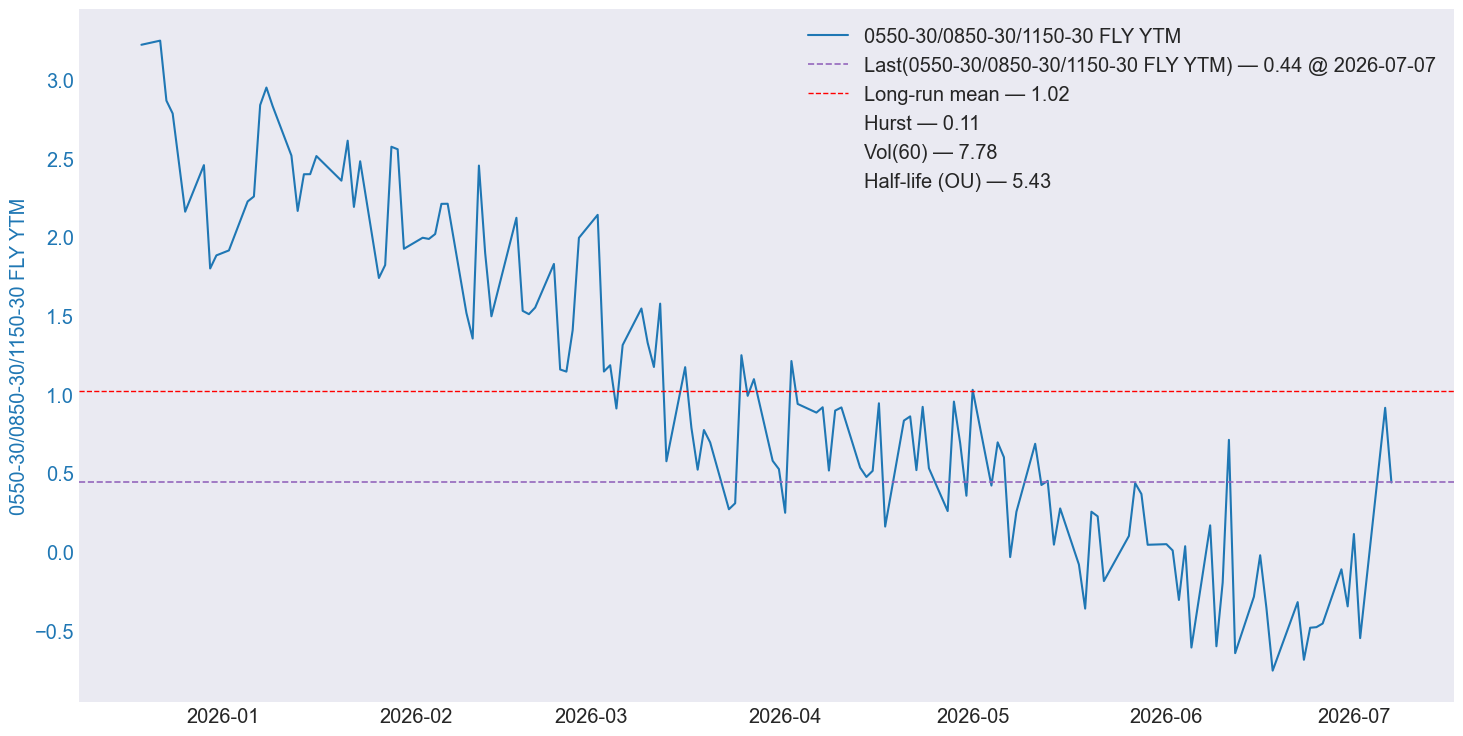

In [27]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

end = datetime.date(2026, 7, 7)
start = end - datetime.timedelta(days=200)
# start = datetime.date(2024, 1, 1)

# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS)
# q1 = IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER)
# q2 = FixedRateBondQuery(cusip="CT30", value=FixedRateBondValue.YTM)
# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="912810UA4/912810UC0", value=IRSwapValue.MMSS)
# q1 = FixedRateBondQuery(cusip="91282CBL4", value=FixedRateBondValue.YTM)
# q1 = FixedRateBondQuery(cusip="Ox5130/Ox5030", value=FixedRateBondValue.YTM)
# q2 = FixedRateBondQuery(cusip="1129-10/0530-10/0231-10", value=FixedRateBondValue.YTM)
q2 = FixedRateBondQuery(cusip="0550-30/0850-30/1150-30", value=FixedRateBondValue.YTM)
# q2 = FixedRateBondQuery(cusip="0541-20/1141-20/0542-20", value=FixedRateBondValue.YTM)
# q2 = FixedRateBondQuery(cusip="0850-30/1150-30/0251-30", value=FixedRateBondValue.YTM)
# q2 = IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # q,
        # q1,
        q2
    ],
    n_jobs=12,
)
	
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
plot(
    df[q2.col_name()],
    which="left",
    indicators=[
        {"kind": "last", "show_date": True, "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},
        # {"kind": "sma", "window": 20, "style": {"linestyle": "--", "color": "red"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "cum_change", "from_at": "2025-09-24", "label": "Chg from Logan TCGR Speech"},
        {"kind": "hurst", "hide": True},
        {"kind": "vol", "returns": "normal", "window": 60, "hide": True},
        {"kind": "half_life", "method": "ou", "demean": True, "style": {"linestyle": ":"}, "hide": True},
    ],
    # ou={"enable": True, "steps": 90, "add_metrics_to_legend": True}
)

# legend(show_date=True)
legend()
plt.show()

In [19]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
seasonality_df = monthend_cumsum_seasonality(df.dropna(), window=25)
display(seasonality_df)

fig = go.Figure()

me_col = f"avg"
# me_col = "avg-nov"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

n_last = 24
monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
monthly_cols = sorted(monthly_cols)  # chronological
keep = monthly_cols[-n_last:] if n_last > 0 else []

# keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-25,0.680488,-0.25944,1.620416,-1.199369,2.560345,1.677044,0.976135,2.377952,0.275226,3.078861,...,0.750931,1.002932,1.118119,1.181426,0.216068,1.195717,-0.219345,1.352011,0.311174,0.0
-24,0.442481,-0.221052,1.106013,-0.884584,1.769545,1.104353,0.664675,1.544031,0.224997,1.98371,...,0.437037,0.871065,0.881011,0.793454,0.422851,0.875227,-0.051531,1.069336,1.028583,-0.011476
-23,0.721223,-0.044326,1.486772,-0.809875,2.252321,1.465983,1.284981,1.646986,1.103978,1.827988,...,0.35654,1.062117,0.336531,1.337995,0.011246,1.117894,0.784492,0.871928,1.150572,0.287418
-22,0.379349,-0.351522,1.11022,-1.082393,1.841091,1.03826,1.005298,1.071221,0.972337,1.104183,...,-0.08364,0.870781,-0.513999,1.014952,-0.181015,1.024445,-0.445175,0.668984,0.731363,0.144853
-21,0.425829,-0.307696,1.159354,-1.041221,1.892879,0.515535,0.402295,0.628776,0.289054,0.742016,...,0.617,0.933004,0.706925,0.435462,0.201543,1.38972,0.073433,1.052777,0.440988,0.102506
-20,0.474752,-0.524565,1.474068,-1.523882,2.473385,0.577009,0.153442,1.000576,-0.270125,1.424143,...,0.288102,1.224003,0.348314,0.277502,0.047801,1.198006,-0.431252,0.987511,0.923415,0.147955
-19,0.488538,-0.402248,1.379323,-1.293033,2.270109,0.970633,0.550659,1.390607,0.130685,1.810581,...,-0.273922,0.536422,1.403037,1.2676,-0.710128,0.49105,-0.178528,1.202855,0.634112,0.407572
-18,0.490981,-0.334175,1.316136,-1.15933,2.141292,0.354949,-0.527132,1.237031,-1.409213,2.119112,...,0.796029,0.400832,1.013788,0.978675,-0.550278,0.730324,0.202521,1.362496,0.059177,0.631122
-17,0.49393,-0.285505,1.273364,-1.06494,2.052799,-0.102434,-0.88116,0.676292,-1.659886,1.455018,...,0.2511,0.384331,1.619444,0.448209,-0.2575,0.847832,-0.035669,1.252251,0.220956,<NA>
